In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
print(os.getcwd())

c:\Users\Abhishek\Downloads\Fam_Intern\notebooks


In [3]:
transactions = pd.read_csv(r"../data/fam_transactions.csv")

In [4]:
users=pd.read_csv(r'../data/fam_users.csv')

In [5]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5371937 entries, 0 to 5371936
Data columns (total 9 columns):
 #   Column            Dtype  
---  ------            -----  
 0   transaction_id    object 
 1   user_id           object 
 2   transaction_date  object 
 3   amount            float64
 4   payment_method    object 
 5   transaction_type  object 
 6   merchant          object 
 7   status            object 
 8   failure_reason    object 
dtypes: float64(1), object(8)
memory usage: 368.9+ MB


In [6]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   user_id                      500000 non-null  object 
 1   registration_date            500000 non-null  object 
 2   age_group                    500000 non-null  object 
 3   city                         500000 non-null  object 
 4   device_type                  500000 non-null  object 
 5   days_since_registration      500000 non-null  int64  
 6   app_opens_per_week           500000 non-null  int64  
 7   avg_session_duration         500000 non-null  float64
 8   support_tickets              500000 non-null  int64  
 9   referrals_made               500000 non-null  int64  
 10  has_customized_card          500000 non-null  int64  
 11  has_set_savings_goal         500000 non-null  int64  
 12  has_used_offers              500000 non-null  int64  
 13 

# Basic Univarient Analysis (For Each feature)

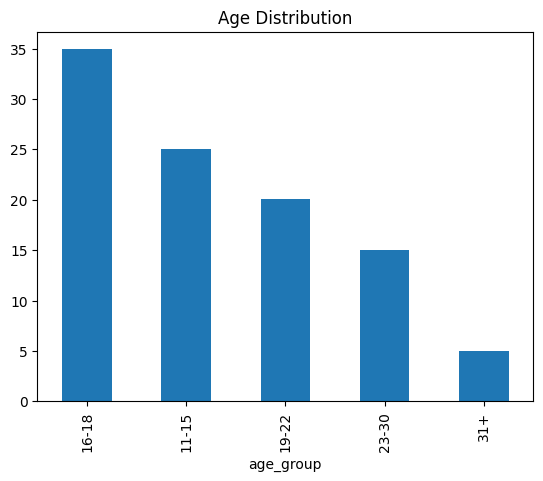

In [7]:
(users["age_group"].value_counts(normalize=True) * 100).plot(kind="bar", title="Age Distribution")
plt.show()


#### more teens about ~ 80% -> Prone to higher churn

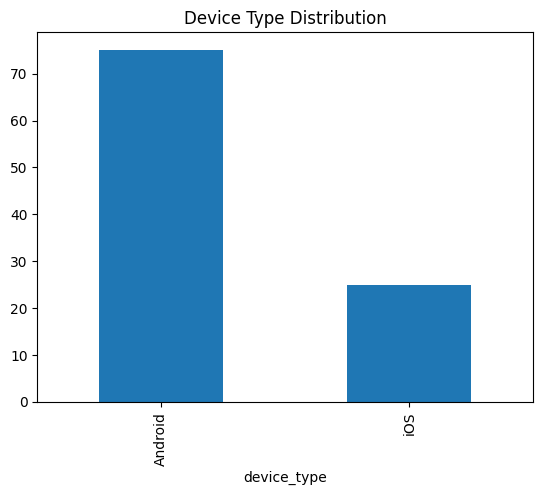

In [8]:
(users["device_type"].value_counts(normalize=True)*100).plot(kind="bar", title="Device Type Distribution")
plt.show()


#### Same for android user


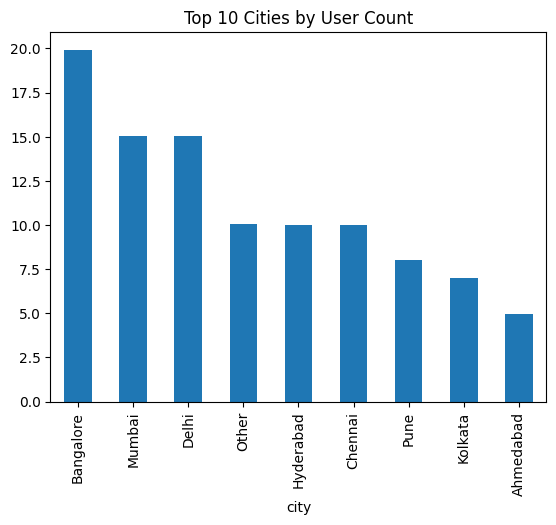

In [9]:
(users["city"].value_counts(normalize=True)*100).head(10).plot(kind="bar", title="Top 10 Cities by User Count")
plt.show()


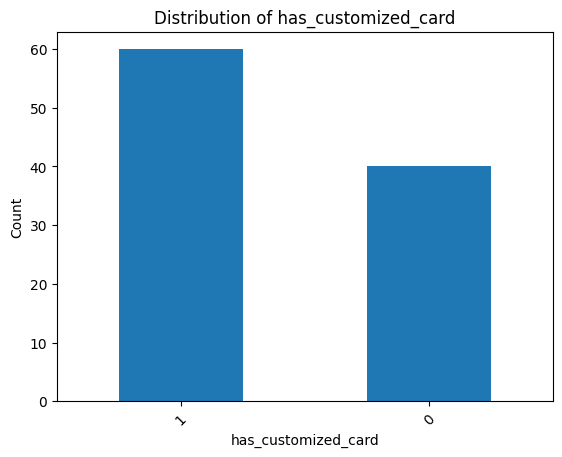

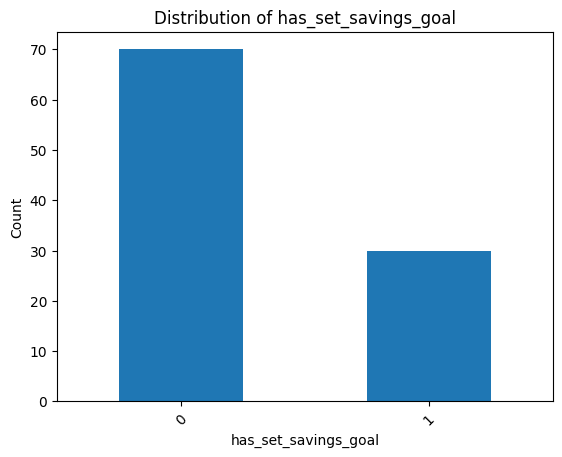

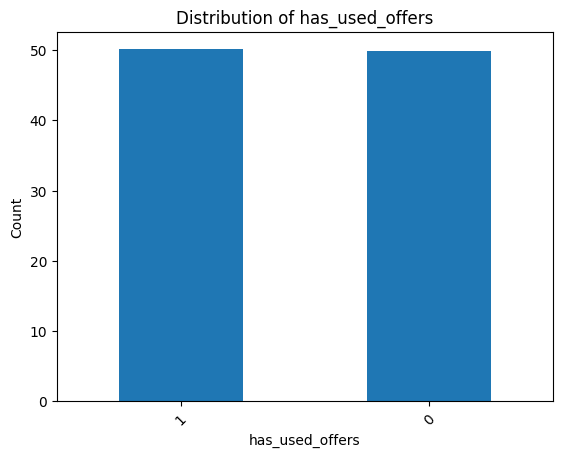

In [10]:
categorical_cols = ["has_customized_card", "has_set_savings_goal", "has_used_offers"]

for col in categorical_cols:
    (users[col].value_counts(normalize=True)*100).plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()


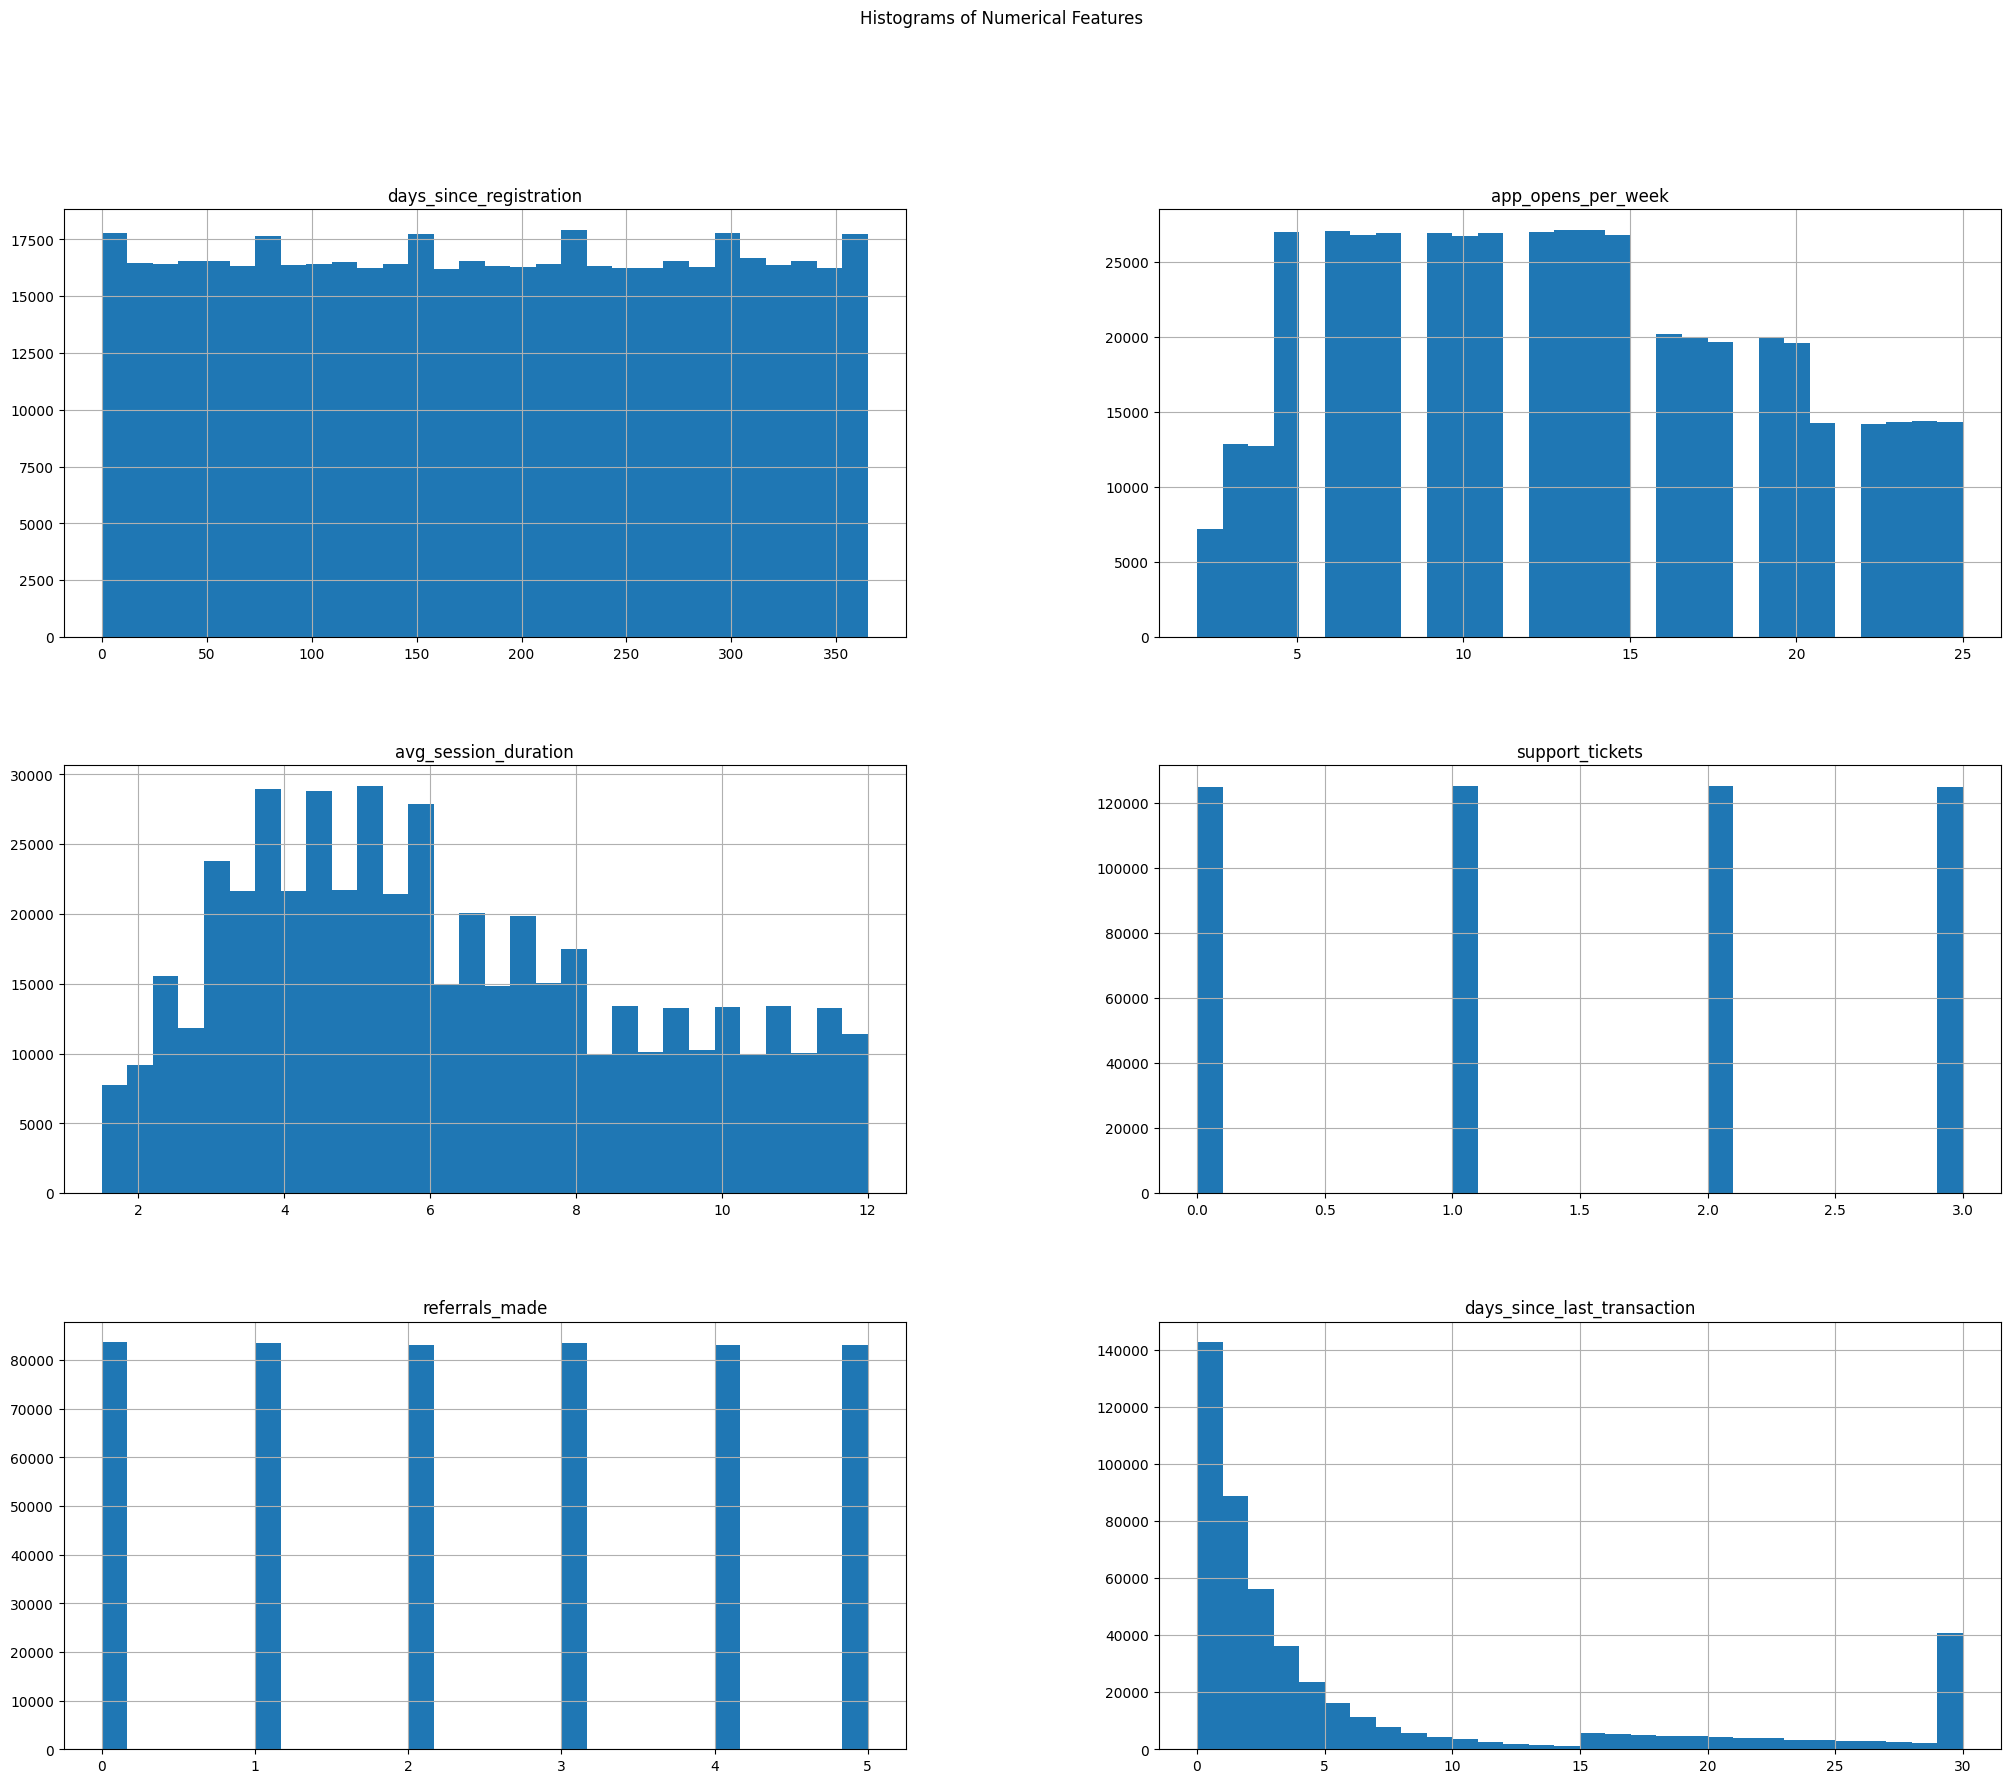

In [11]:
# Numerical features
numeric_cols = ["days_since_registration", "app_opens_per_week", "avg_session_duration",
                "support_tickets", "referrals_made", "days_since_last_transaction"]

users[numeric_cols].hist(bins=30, figsize=(25, 20))
plt.suptitle("Histograms of Numerical Features")
plt.show()




### days_since_last_transaction, avrage screen duration and app open per week could be possible good features for the analysis

### Target Variable

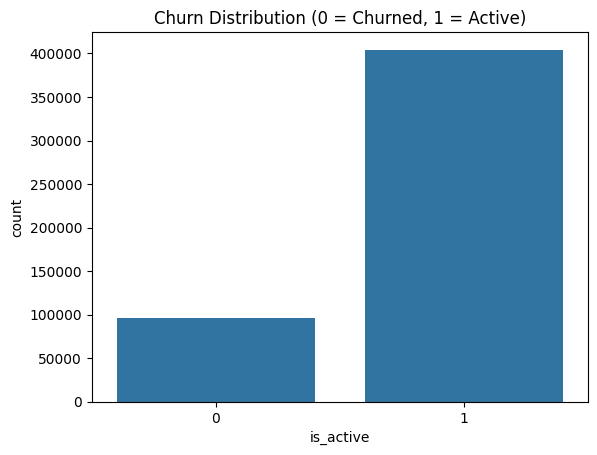

In [12]:
sns.countplot(x="is_active", data=users)
plt.title("Churn Distribution (0 = Churned, 1 = Active)")
plt.show()

### Imbalance data we will take care of it in next notebook

### Categorical vs Churn

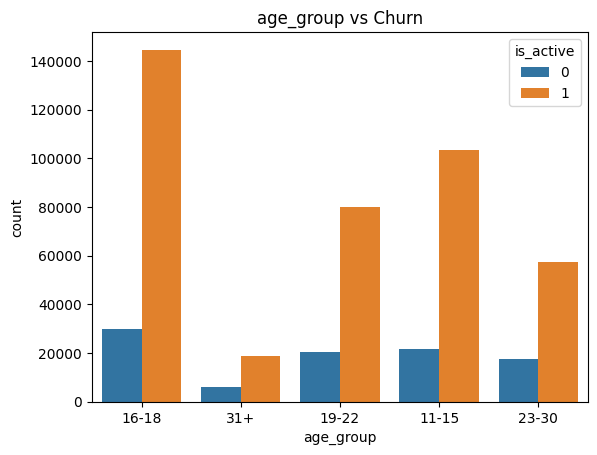

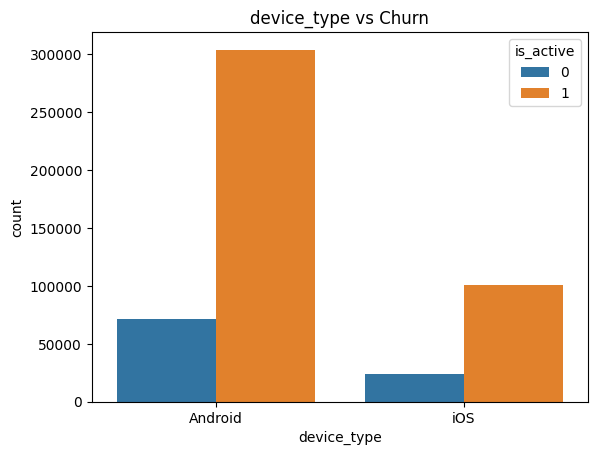

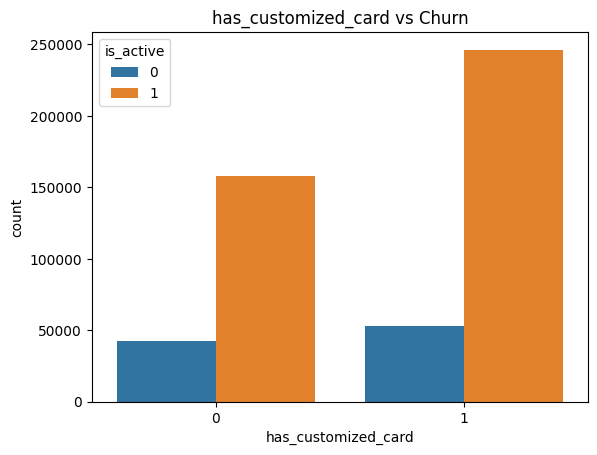

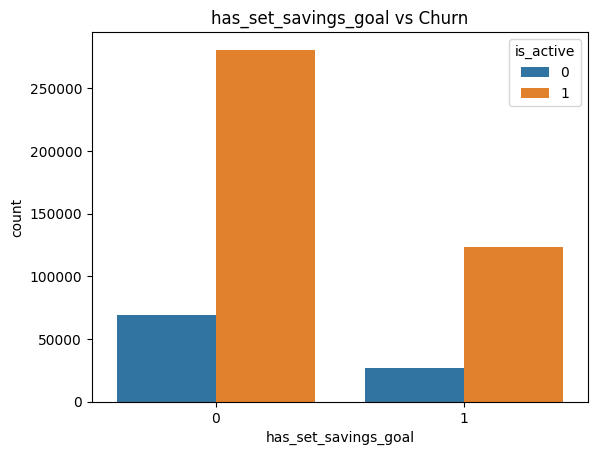

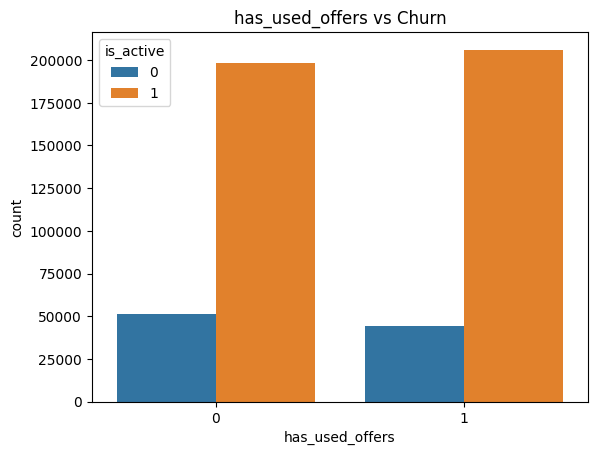

In [13]:

for col in ["age_group", "device_type", "has_customized_card", "has_set_savings_goal", "has_used_offers"]:
    sns.countplot(x=col, hue="is_active", data=users)
    plt.title(f"{col} vs Churn")
    plt.xticks()
    plt.show()


In [14]:
columns = ["age_group", "device_type", "has_customized_card", "has_set_savings_goal", "has_used_offers"]

percentage_churn = {}

for col in columns:
    churn_percent = users.groupby(col)["is_active"].apply(lambda x: (x == 0).mean() * 100)
    percentage_churn[col] = churn_percent

for col, percent in percentage_churn.items():
    print(f"\nChurn percentage for {col}:")
    print(percent)



Churn percentage for age_group:
age_group
11-15    17.253079
16-18    17.159560
19-22    20.265182
23-30    23.547914
31+      23.954662
Name: is_active, dtype: float64

Churn percentage for device_type:
device_type
Android    19.095580
iOS        19.131029
Name: is_active, dtype: float64

Churn percentage for has_customized_card:
has_customized_card
0    21.106569
1    17.765935
Name: is_active, dtype: float64

Churn percentage for has_set_savings_goal:
has_set_savings_goal
0    19.741620
1    17.617171
Name: is_active, dtype: float64

Churn percentage for has_used_offers:
has_used_offers
0    20.548231
1    17.665148
Name: is_active, dtype: float64


### Almost equal(17-23 ie variation is less) churn percentage across all the groups 

### Numerical vs Churn

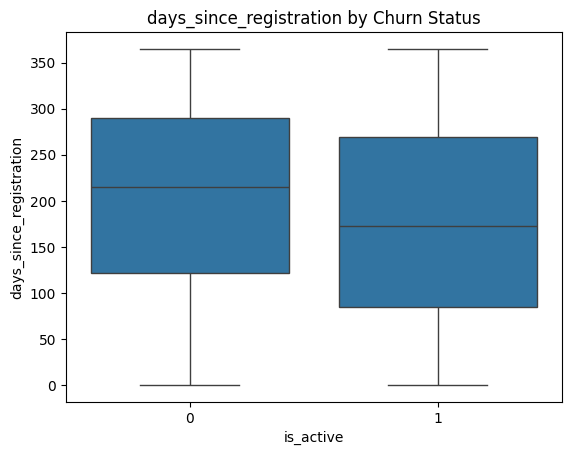

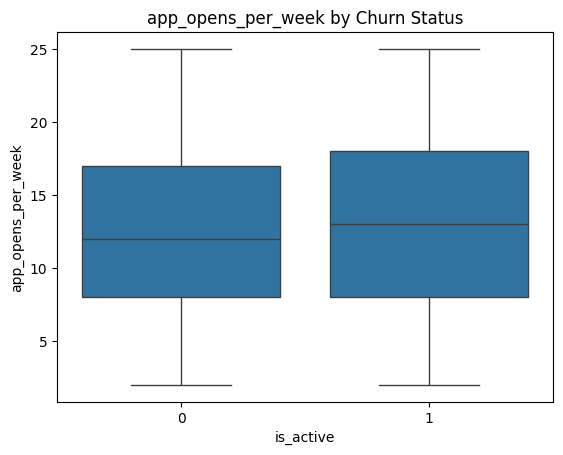

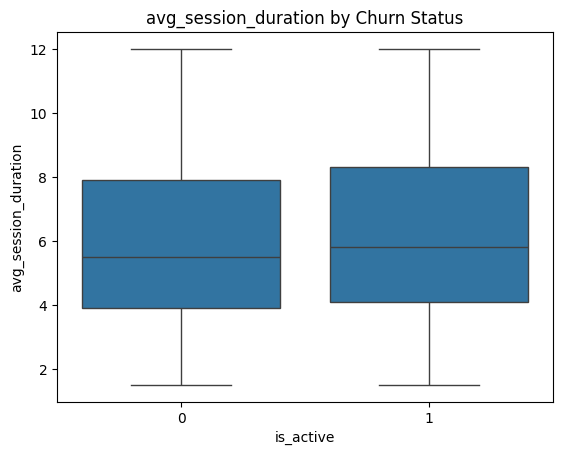

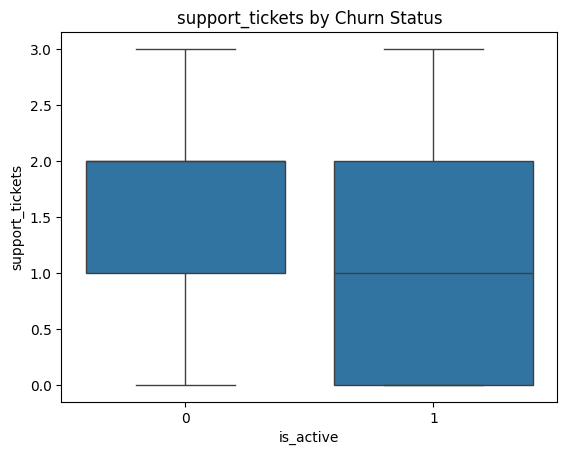

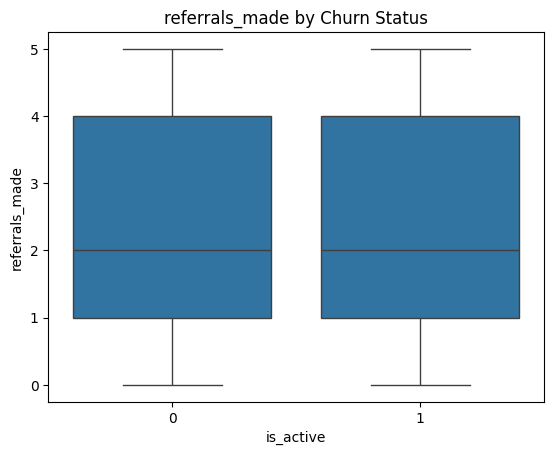

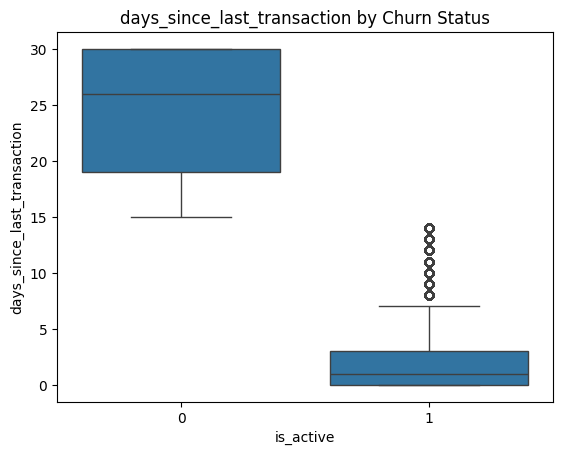

In [15]:
for col in numeric_cols:
    sns.boxplot(x="is_active", y=col, data=users)
    plt.title(f"{col} by Churn Status")
    plt.show()

#### days_since_last_transaction definetaly a good feature as we can see a very clear seperation here based on churn though ther are some outliers also

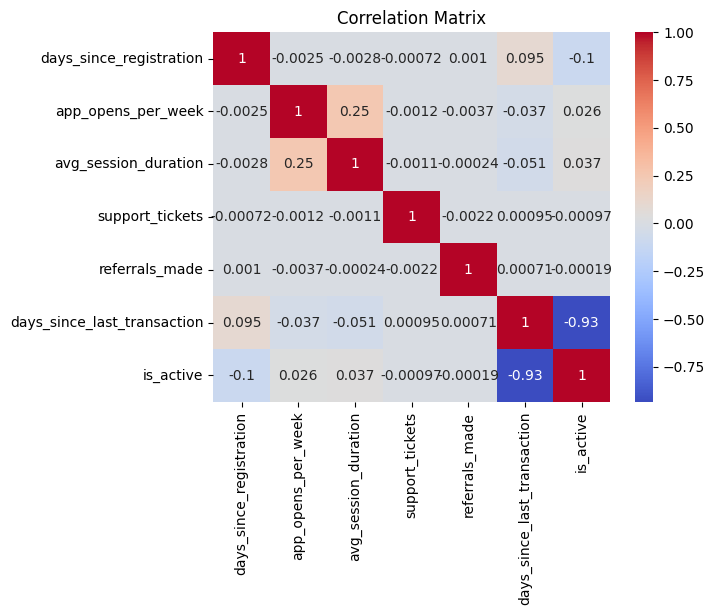

In [16]:
corr = users[numeric_cols + ["is_active"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


### Not much correlation between the columns expert except for the is_active and Days_since_transaction

## Lets Focus on the second table now

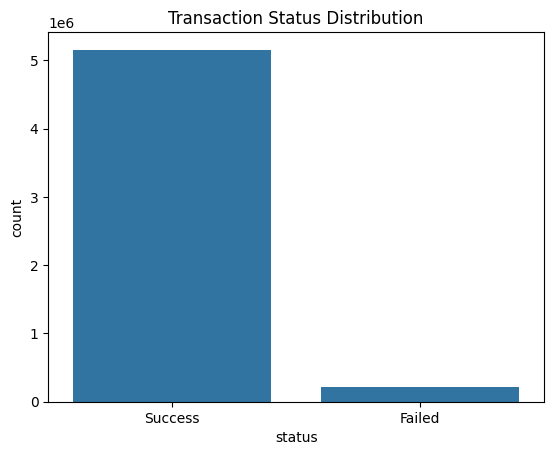

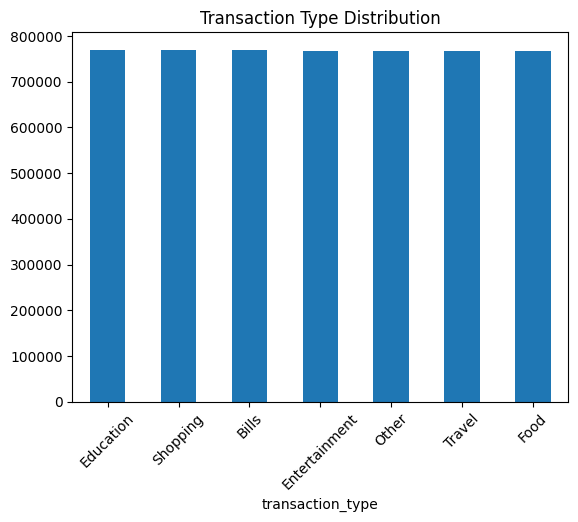

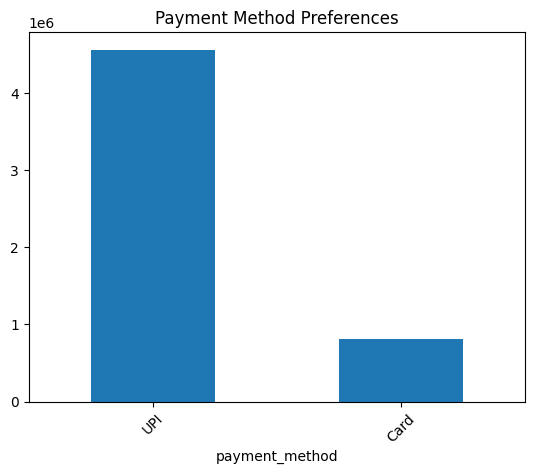

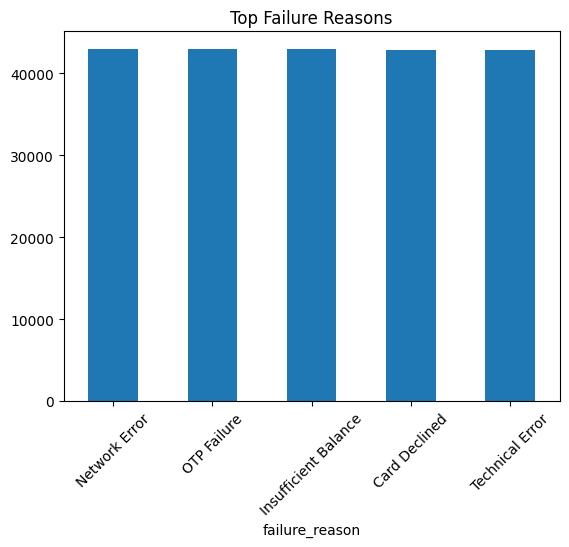

In [17]:
# Transaction Status
sns.countplot(x="status", data=transactions)
plt.title("Transaction Status Distribution")
plt.show()

# Transaction Type
transactions["transaction_type"].value_counts().plot(kind="bar")
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.show()

# Payment Method
transactions["payment_method"].value_counts().plot(kind="bar")
plt.title("Payment Method Preferences")
plt.xticks(rotation=45)
plt.show()

# Failed transaction reasons
failed = transactions[transactions["status"] == "Failed"]
failed["failure_reason"].value_counts().plot(kind="bar")
plt.title("Top Failure Reasons")
plt.xticks(rotation=45)
plt.show()


In [18]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

In [19]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5371937 entries, 0 to 5371936
Data columns (total 9 columns):
 #   Column            Dtype         
---  ------            -----         
 0   transaction_id    object        
 1   user_id           object        
 2   transaction_date  datetime64[ns]
 3   amount            float64       
 4   payment_method    object        
 5   transaction_type  object        
 6   merchant          object        
 7   status            object        
 8   failure_reason    object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 368.9+ MB


### Lets create some new featurs here like

- total_transactions and total_amount / avg_amount / max_amount / min_amount

- active_days
    
- transaction_failure_rate 

- etc ............

In [20]:
agg_txn = transactions.groupby('user_id').agg(
    total_transactions=('transaction_id', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max'),
    min_amount=('amount', 'min'),
    active_days=('transaction_date', lambda x: x.nunique()),
    unique_merchants=('merchant', 'nunique'),
    transaction_failure_rate=('status', lambda x: (x == 'failed').mean()),
    most_common_payment_method=('payment_method', lambda x: x.mode()[0] if not x.mode().empty else 'unknown'),
    most_common_transaction_type=('transaction_type', lambda x: x.mode()[0] if not x.mode().empty else 'unknown'),
    last_transaction_date=('transaction_date', 'max'),
    first_transaction_date=('transaction_date', 'min')
)


In [33]:
agg_txn['days_between_first_and_last_txn'] = (
    agg_txn['last_transaction_date'] - agg_txn['first_transaction_date']
).dt.days

agg_txn['days_since_last_transaction'] = (
    pd.to_datetime("today") - agg_txn['last_transaction_date']
).dt.days


In [34]:
agg_txn = agg_txn.reset_index()


In [35]:
agg_txn

,index,user_id,total_transactions,total_amount,avg_amount,max_amount,min_amount,active_days,unique_merchants,transaction_failure_rate,most_common_payment_method,most_common_transaction_type,last_transaction_date,first_transaction_date,days_between_first_and_last_txn,days_since_last_transaction
0,0,U000001,18,9262.26,514.570000,923.55,169.12,13,12,0.0,UPI,Bills,2025-05-19 15:21:09.617688,2025-04-20 15:21:09.617688,29,8
1,1,U000002,2,17914.55,8957.275000,9998.41,7916.14,2,2,0.0,Card,Education,2025-05-01 15:21:09.617688,2025-04-27 15:21:09.617688,4,26
2,2,U000004,7,3156.55,450.935714,704.84,156.91,6,7,0.0,UPI,Food,2025-05-19 15:21:09.617688,2025-04-19 15:21:09.617688,30,8
3,3,U000006,2,500.25,250.125000,253.79,246.46,2,2,0.0,UPI,Shopping,2025-05-03 15:21:09.617688,2025-04-21 15:21:09.617688,12,24
4,4,U000008,9,26902.76,2989.195556,4662.19,740.65,8,8,0.0,UPI,Education,2025-05-10 15:21:09.617688,2025-04-20 15:21:09.617688,20,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463303,463303,U499996,19,21670.68,1140.562105,1984.87,406.28,14,15,0.0,UPI,Education,2025-05-19 15:21:09.617688,2025-04-19 15:21:09.617688,30,8
463304,463304,U499997,14,71326.65,5094.760714,9372.46,1910.39,11,13,0.0,UPI,Food,2025-05-18 15:21:09.617688,2025-04-20 15:21:09.617688,28,9
463305,463305,U499998,11,5972.15,542.922727,950.79,267.58,11,7,0.0,UPI,Travel,2025-05-15 15:21:09.617688,2025-04-19 15:21:09.617688,26,12
463306,463306,U499999,6,5219.12,869.853333,1646.93,334.77,6,5,0.0,UPI,Education,2025-05-14 15:21:09.617688,2025-04-20 15:21:09.617688,24,13


In [36]:
agg_txn.to_csv("../data/merge_transactions.csv", index=False)

## Merge Two Tables

In [37]:
new_transaction=pd.read_csv("../data/merge_transactions.csv")

In [38]:
new_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463308 entries, 0 to 463307
Data columns (total 16 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   index                            463308 non-null  int64  
 1   user_id                          463308 non-null  object 
 2   total_transactions               463308 non-null  int64  
 3   total_amount                     463308 non-null  float64
 4   avg_amount                       463308 non-null  float64
 5   max_amount                       463308 non-null  float64
 6   min_amount                       463308 non-null  float64
 7   active_days                      463308 non-null  int64  
 8   unique_merchants                 463308 non-null  int64  
 9   transaction_failure_rate         463308 non-null  float64
 10  most_common_payment_method       463308 non-null  object 
 11  most_common_transaction_type     463308 non-null  object 
 12  la

In [39]:
df = pd.merge(users, new_transaction, on='user_id', how='left')

In [40]:
df

,user_id,registration_date,age_group,city,device_type,days_since_registration,app_opens_per_week,avg_session_duration,support_tickets,referrals_made,...,min_amount,active_days,unique_merchants,transaction_failure_rate,most_common_payment_method,most_common_transaction_type,last_transaction_date,first_transaction_date,days_between_first_and_last_txn,days_since_last_transaction_y
0,U000001,2025-04-11 15:21:09.617688,16-18,Mumbai,Android,38,11,5.3,3,0,...,169.12,13.0,12.0,0.0,UPI,Bills,2025-05-19 15:21:09.617688,2025-04-20 15:21:09.617688,29.0,8.0
1,U000002,2024-07-15 15:21:09.617688,31+,Hyderabad,Android,308,14,5.4,0,1,...,7916.14,2.0,2.0,0.0,Card,Education,2025-05-01 15:21:09.617688,2025-04-27 15:21:09.617688,4.0,26.0
2,U000003,2024-05-31 15:21:09.617688,19-22,Chennai,Android,353,3,5.8,2,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,U000004,2024-10-06 15:21:09.617688,16-18,Other,Android,225,25,10.5,3,3,...,156.91,6.0,7.0,0.0,UPI,Food,2025-05-19 15:21:09.617688,2025-04-19 15:21:09.617688,30.0,8.0
4,U000005,2024-09-21 15:21:09.617688,11-15,Chennai,iOS,240,23,3.8,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,U499996,2025-01-27 15:21:09.617688,19-22,Ahmedabad,iOS,112,11,3.1,2,2,...,406.28,14.0,15.0,0.0,UPI,Education,2025-05-19 15:21:09.617688,2025-04-19 15:21:09.617688,30.0,8.0
499996,U499997,2024-11-22 15:21:09.617688,31+,Delhi,Android,178,3,4.0,0,4,...,1910.39,11.0,13.0,0.0,UPI,Food,2025-05-18 15:21:09.617688,2025-04-20 15:21:09.617688,28.0,9.0
499997,U499998,2024-12-09 15:21:09.617688,16-18,Delhi,Android,161,20,11.2,0,3,...,267.58,11.0,7.0,0.0,UPI,Travel,2025-05-15 15:21:09.617688,2025-04-19 15:21:09.617688,26.0,12.0
499998,U499999,2024-09-16 15:21:09.617688,19-22,Delhi,Android,245,18,2.5,2,1,...,334.77,6.0,5.0,0.0,UPI,Education,2025-05-14 15:21:09.617688,2025-04-20 15:21:09.617688,24.0,13.0


In [41]:
df.isnull().sum()

user_id                                0
registration_date                      0
age_group                              0
city                                   0
device_type                            0
days_since_registration                0
app_opens_per_week                     0
avg_session_duration                   0
support_tickets                        0
referrals_made                         0
has_customized_card                    0
has_set_savings_goal                   0
has_used_offers                        0
days_since_last_transaction_x          0
is_active                              0
index                              36692
total_transactions                 36692
total_amount                       36692
avg_amount                         36692
max_amount                         36692
min_amount                         36692
active_days                        36692
unique_merchants                   36692
transaction_failure_rate           36692
most_common_paym

### so there are 36692 rows having the null value which is (37000/500000)~ 8% which can be ignore for the analysis, better to drop

In [42]:
df = df.dropna()

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463308 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   user_id                          463308 non-null  object 
 1   registration_date                463308 non-null  object 
 2   age_group                        463308 non-null  object 
 3   city                             463308 non-null  object 
 4   device_type                      463308 non-null  object 
 5   days_since_registration          463308 non-null  int64  
 6   app_opens_per_week               463308 non-null  int64  
 7   avg_session_duration             463308 non-null  float64
 8   support_tickets                  463308 non-null  int64  
 9   referrals_made                   463308 non-null  int64  
 10  has_customized_card              463308 non-null  int64  
 11  has_set_savings_goal             463308 non-null  int64  
 12  has_use

## Let's do an overall final analysis and drop irrelevant columns.

In [44]:
numerical_cols = [
    'days_since_registration', 'app_opens_per_week', 'avg_session_duration',
    'support_tickets', 'referrals_made', 'has_customized_card',
    'has_set_savings_goal', 'has_used_offers', 'days_since_last_transaction_x',
    'is_active', 'total_transactions', 'total_amount', 'avg_amount',
    'max_amount', 'min_amount', 'active_days', 'unique_merchants',
    'transaction_failure_rate', 'days_between_first_and_last_txn',
    'days_since_last_transaction_y'
]

In [45]:
categorical_cols = [
 'registration_date', 'age_group', 'city', 'device_type',
    'most_common_payment_method', 'most_common_transaction_type',
    'last_transaction_date', 'first_transaction_date'
]

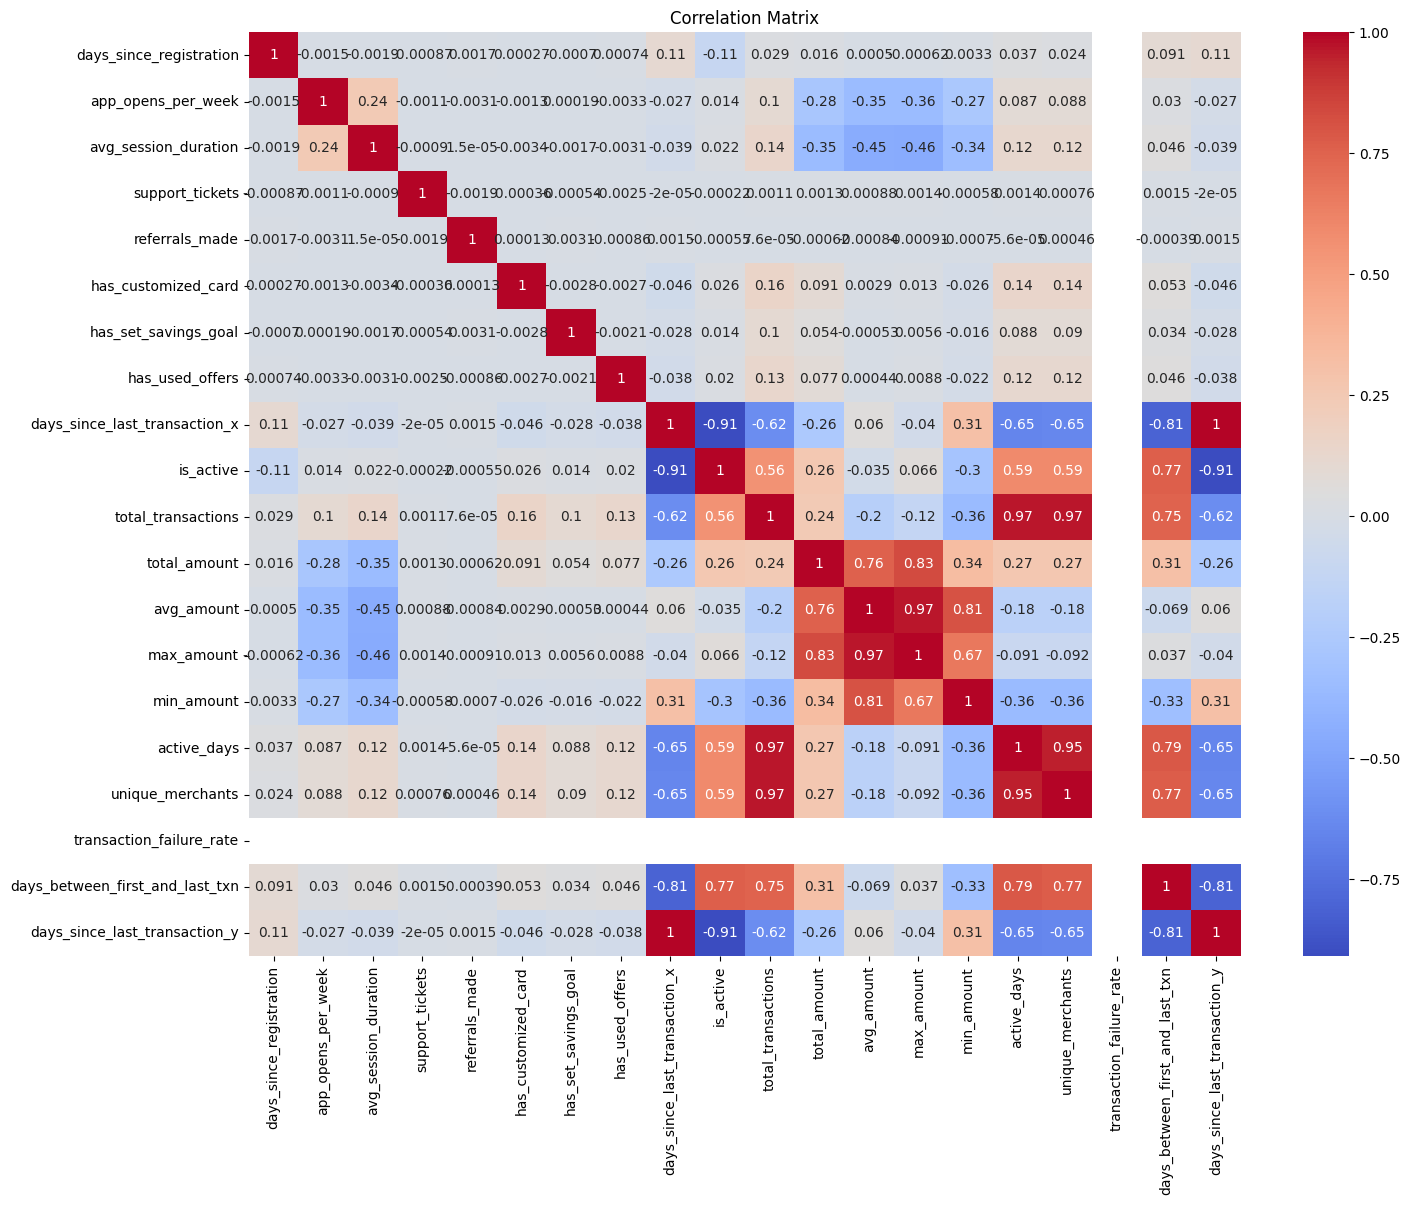

In [46]:
corr = df[numerical_cols].corr()
plt.figure(figsize=(16, 12)) 
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Top feature
- Positive Corr -> active_days, unique_merchants, total_transactions , days_between_first_and_last_txn , toatl_transction

- Negative Corr -> days_since_last_transaction_x/y

In [47]:
target_corr = corr["is_active"]
target_corr

days_since_registration           -0.107015
app_opens_per_week                 0.013880
avg_session_duration               0.021778
support_tickets                   -0.000220
referrals_made                    -0.000551
has_customized_card                0.025562
has_set_savings_goal               0.014474
has_used_offers                    0.020091
days_since_last_transaction_x     -0.909160
is_active                          1.000000
total_transactions                 0.555516
total_amount                       0.256942
avg_amount                        -0.035225
max_amount                         0.066449
min_amount                        -0.295004
active_days                        0.591649
unique_merchants                   0.594726
transaction_failure_rate                NaN
days_between_first_and_last_txn    0.766203
days_since_last_transaction_y     -0.909160
Name: is_active, dtype: float64

In [48]:
weak_corr_features = target_corr[(target_corr > -0.5) & (target_corr < 0.5)].index.tolist()
weak_corr_features = [col for col in weak_corr_features if col != "is_active"]
df = df.drop(columns=weak_corr_features)

In [49]:
weak_corr_features

['days_since_registration',
 'app_opens_per_week',
 'avg_session_duration',
 'support_tickets',
 'referrals_made',
 'has_customized_card',
 'has_set_savings_goal',
 'has_used_offers',
 'total_amount',
 'avg_amount',
 'max_amount',
 'min_amount']

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463308 entries, 0 to 499999
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   user_id                          463308 non-null  object 
 1   registration_date                463308 non-null  object 
 2   age_group                        463308 non-null  object 
 3   city                             463308 non-null  object 
 4   device_type                      463308 non-null  object 
 5   days_since_last_transaction_x    463308 non-null  int64  
 6   is_active                        463308 non-null  int64  
 7   index                            463308 non-null  float64
 8   total_transactions               463308 non-null  float64
 9   active_days                      463308 non-null  float64
 10  unique_merchants                 463308 non-null  float64
 11  transaction_failure_rate         463308 non-null  float64
 12  most_co

In [51]:
strong_corr_cols = [col for col in numerical_cols if col not in weak_corr_features]
strong_corr_cols

['days_since_last_transaction_x',
 'is_active',
 'total_transactions',
 'active_days',
 'unique_merchants',
 'transaction_failure_rate',
 'days_between_first_and_last_txn',
 'days_since_last_transaction_y']

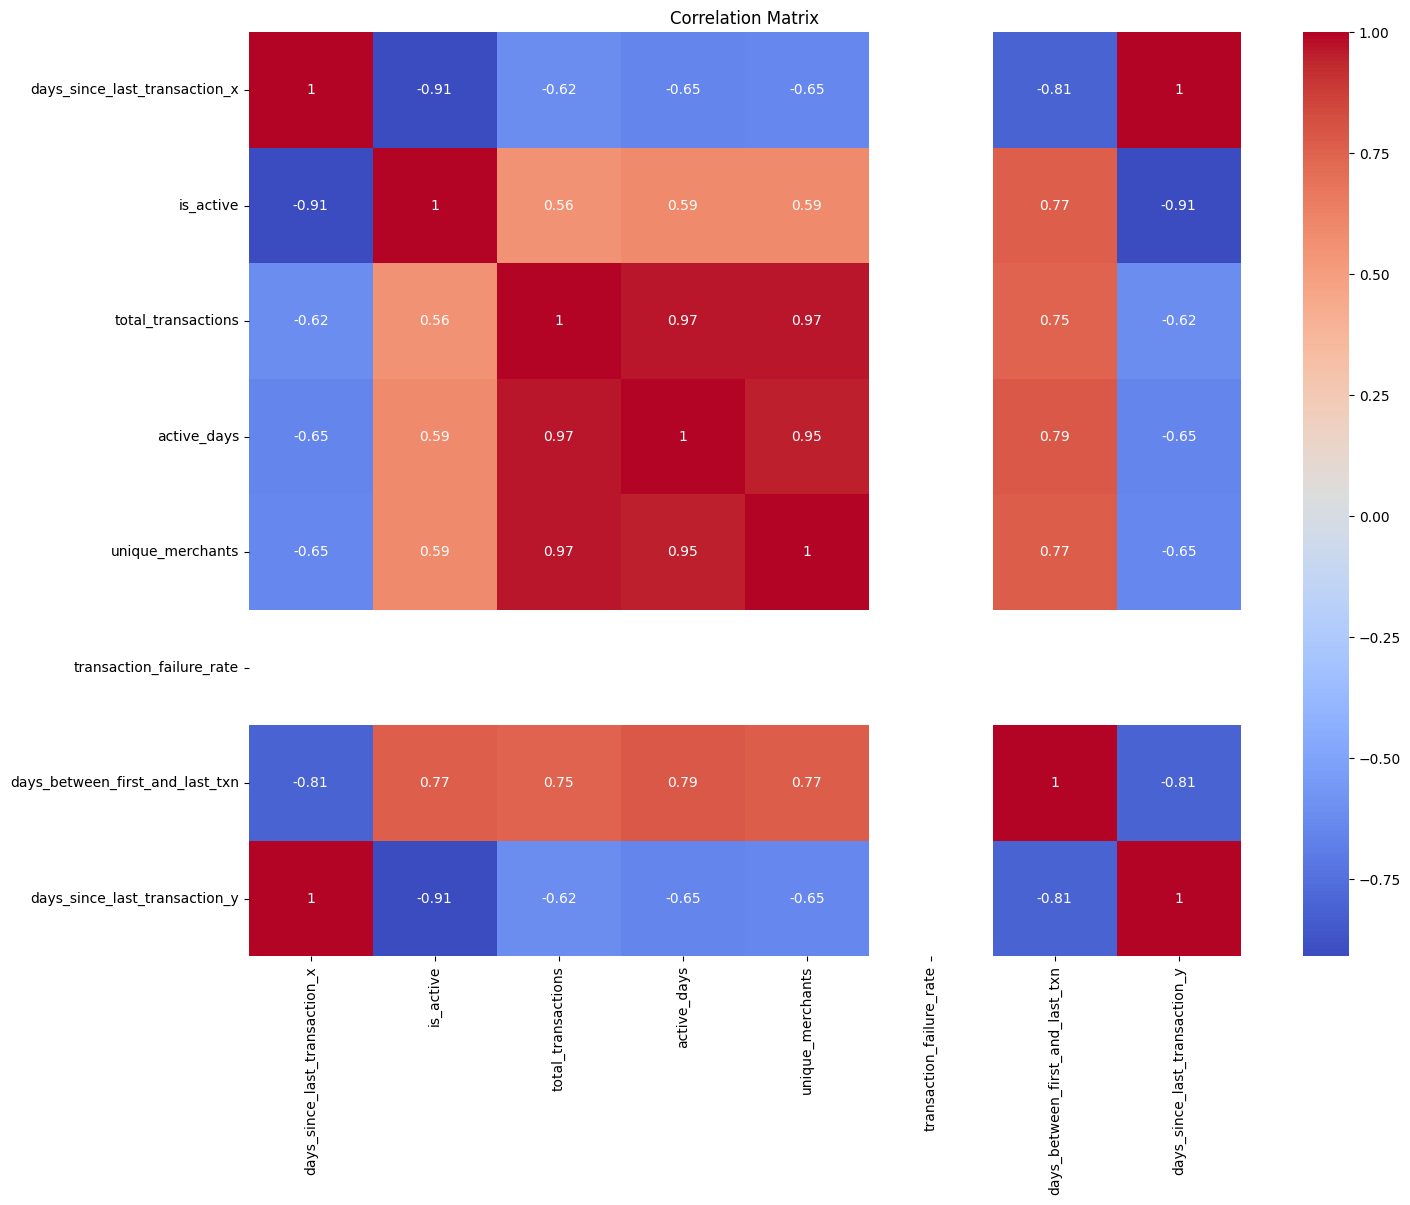

In [52]:
corr = df[strong_corr_cols].corr()
plt.figure(figsize=(16, 12)) 
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [53]:
(df['transaction_failure_rate'] == 0).all()

np.True_

### I have checked transaction_failure_rate has all value zero only so better to drop

In [54]:
df = df.drop(columns='transaction_failure_rate')

In [55]:
strong_corr_cols= ['days_since_last_transaction_x',
 'is_active',
 'total_transactions',
 'active_days',
 'unique_merchants',
 'days_between_first_and_last_txn',
 'days_since_last_transaction_y']

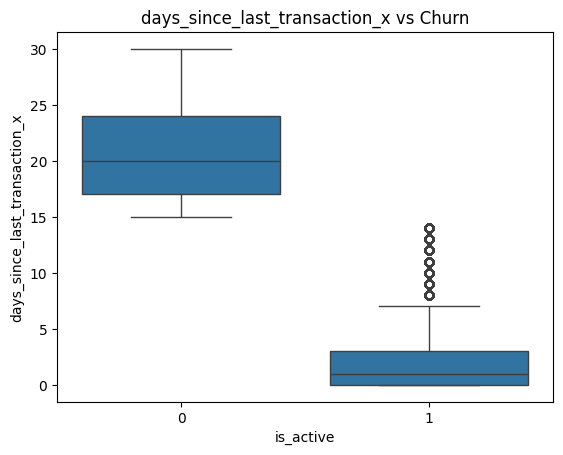

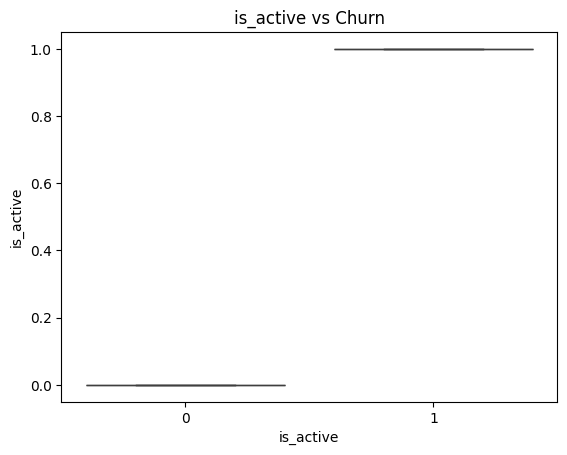

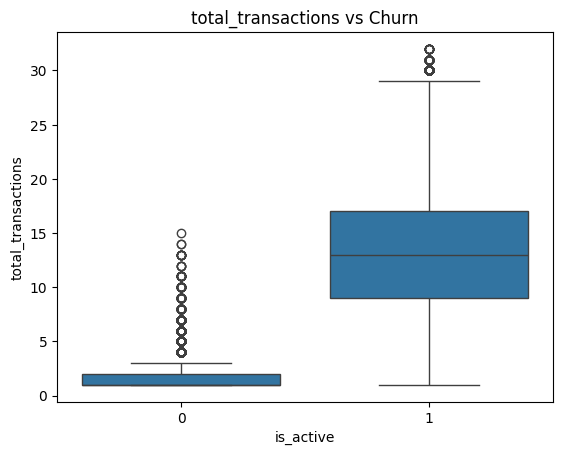

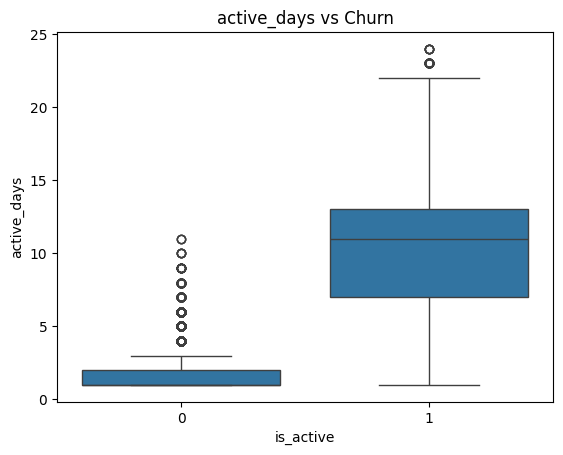

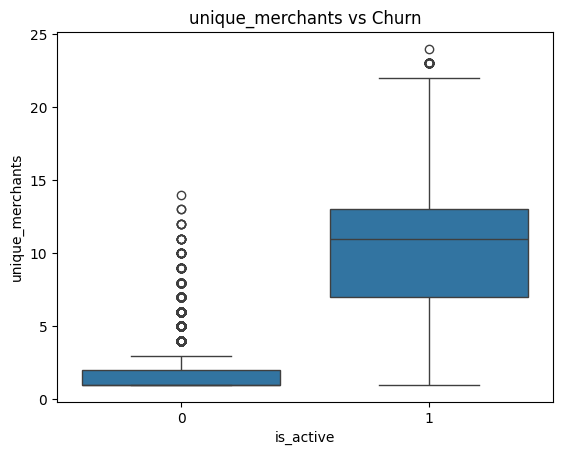

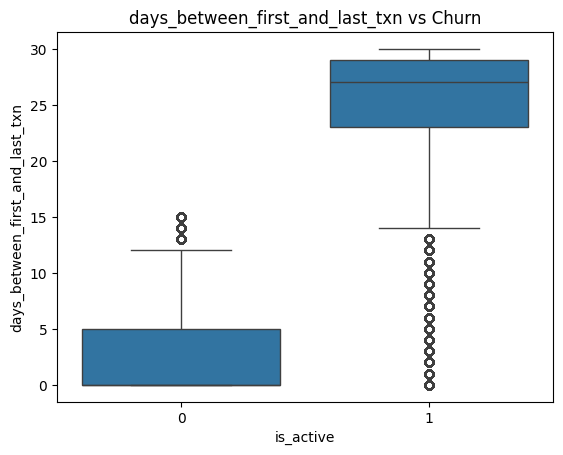

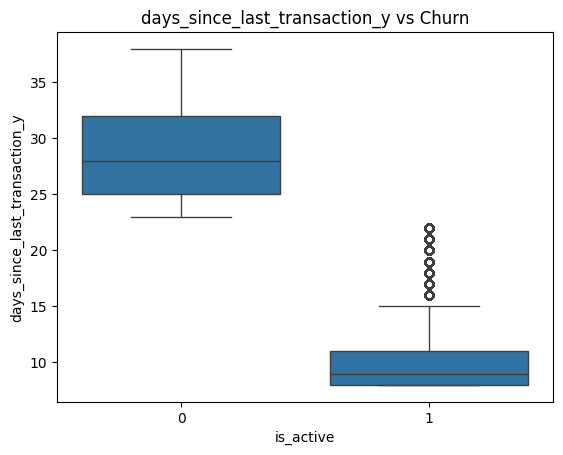

In [56]:
for col in strong_corr_cols:
    sns.boxplot(x="is_active", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

## Lets do for Catogorical Column 

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder

In [58]:
df

,user_id,registration_date,age_group,city,device_type,days_since_last_transaction_x,is_active,index,total_transactions,active_days,unique_merchants,most_common_payment_method,most_common_transaction_type,last_transaction_date,first_transaction_date,days_between_first_and_last_txn,days_since_last_transaction_y
0,U000001,2025-04-11 15:21:09.617688,16-18,Mumbai,Android,0,1,0.0,18.0,13.0,12.0,UPI,Bills,2025-05-19 15:21:09.617688,2025-04-20 15:21:09.617688,29.0,8.0
1,U000002,2024-07-15 15:21:09.617688,31+,Hyderabad,Android,18,0,1.0,2.0,2.0,2.0,Card,Education,2025-05-01 15:21:09.617688,2025-04-27 15:21:09.617688,4.0,26.0
3,U000004,2024-10-06 15:21:09.617688,16-18,Other,Android,0,1,2.0,7.0,6.0,7.0,UPI,Food,2025-05-19 15:21:09.617688,2025-04-19 15:21:09.617688,30.0,8.0
5,U000006,2024-09-10 15:21:09.617688,11-15,Delhi,Android,16,0,3.0,2.0,2.0,2.0,UPI,Shopping,2025-05-03 15:21:09.617688,2025-04-21 15:21:09.617688,12.0,24.0
7,U000008,2024-07-10 15:21:09.617688,23-30,Mumbai,Android,9,1,4.0,9.0,8.0,8.0,UPI,Education,2025-05-10 15:21:09.617688,2025-04-20 15:21:09.617688,20.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,U499996,2025-01-27 15:21:09.617688,19-22,Ahmedabad,iOS,0,1,463303.0,19.0,14.0,15.0,UPI,Education,2025-05-19 15:21:09.617688,2025-04-19 15:21:09.617688,30.0,8.0
499996,U499997,2024-11-22 15:21:09.617688,31+,Delhi,Android,1,1,463304.0,14.0,11.0,13.0,UPI,Food,2025-05-18 15:21:09.617688,2025-04-20 15:21:09.617688,28.0,9.0
499997,U499998,2024-12-09 15:21:09.617688,16-18,Delhi,Android,4,1,463305.0,11.0,11.0,7.0,UPI,Travel,2025-05-15 15:21:09.617688,2025-04-19 15:21:09.617688,26.0,12.0
499998,U499999,2024-09-16 15:21:09.617688,19-22,Delhi,Android,5,1,463306.0,6.0,6.0,5.0,UPI,Education,2025-05-14 15:21:09.617688,2025-04-20 15:21:09.617688,24.0,13.0


In [59]:
X = df[categorical_cols]
y = df['is_active']


In [60]:
X_encoded = X.apply(LabelEncoder().fit_transform)

In [61]:
X_encoded.describe()

,registration_date,age_group,city,device_type,most_common_payment_method,most_common_transaction_type,last_transaction_date,first_transaction_date
count,463308.000000,463308.000000,463308.000000,463308.000000,463308.000000,463308.000000,463308.000000,463308.000000
mean,183.395435,1.382795,3.846202,0.249007,0.961559,2.419313,25.558887,3.847294
std,105.333123,1.150905,2.444820,0.432438,0.192258,1.970146,6.960506,5.552409
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,2.000000,0.000000,1.000000,1.000000,26.000000,0.000000
50%,185.000000,1.000000,4.000000,0.000000,1.000000,2.000000,29.000000,2.000000
75%,275.000000,2.000000,6.000000,0.000000,1.000000,4.000000,30.000000,5.000000
max,365.000000,4.000000,8.000000,1.000000,1.000000,6.000000,30.000000,30.000000


In [63]:
mi = mutual_info_classif(X_encoded, y, discrete_features=True)

for col, score in zip(categorical_cols, mi):
    print(f"Mutual Information of {col}: {score:.4f}")

Mutual Information of registration_date: 0.0120
Mutual Information of age_group: 0.0008
Mutual Information of city: 0.0000
Mutual Information of device_type: 0.0000
Mutual Information of most_common_payment_method: 0.0298
Mutual Information of most_common_transaction_type: 0.0001
Mutual Information of last_transaction_date: 0.3806
Mutual Information of first_transaction_date: 0.0590


### we can drop the feature with very low mutual information but better we check for the p values

In [64]:
coll=['registration_date','last_transaction_date','first_transaction_date'] ## redudent one

In [65]:
df.drop(columns=coll, inplace=True)

In [66]:
categorical_cols = [col for col in categorical_cols if col not in coll]

In [67]:

X_cat = df[categorical_cols]
y = df["is_active"]


ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_ohe = ohe.fit_transform(X_cat)
feature_names = ohe.get_feature_names_out(categorical_cols)


chi2_stats, p_values = chi2(X_ohe, y)


chi2_results = pd.DataFrame({
    'Feature': feature_names,
    'P-Value': p_values
})


chi2_results.sort_values(by='P-Value', inplace=True)


significant_features = chi2_results[chi2_results['P-Value'] < 0.05]

print("Significant categorical features (p < 0.05):")
print(significant_features)


Significant categorical features (p < 0.05):
                                       Feature       P-Value
17              most_common_payment_method_UPI  0.000000e+00
16             most_common_payment_method_Card  0.000000e+00
3                              age_group_23-30  6.080781e-79
4                                age_group_31+  1.026937e-33
1                              age_group_16-18  3.401219e-30
0                              age_group_11-15  6.331502e-21
21           most_common_transaction_type_Food  7.101133e-09
24         most_common_transaction_type_Travel  5.215815e-08
18          most_common_transaction_type_Bills  2.271861e-06
22          most_common_transaction_type_Other  7.831832e-06
2                              age_group_19-22  1.878676e-04
20  most_common_transaction_type_Entertainment  1.000094e-02


#### Create contingency table between feature and target

In [68]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    
    contingency_table = pd.crosstab(df[col], users['is_active'])
    

    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    
    print(f"Feature: {col}, p-value: {p_val:.4f}")


Feature: age_group, p-value: 0.0000
Feature: city, p-value: 0.4823
Feature: device_type, p-value: 0.2349
Feature: most_common_payment_method, p-value: 0.0000
Feature: most_common_transaction_type, p-value: 0.0000


In [69]:
df.drop(columns=['city','device_type'], inplace=True)


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463308 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   user_id                          463308 non-null  object 
 1   age_group                        463308 non-null  object 
 2   days_since_last_transaction_x    463308 non-null  int64  
 3   is_active                        463308 non-null  int64  
 4   index                            463308 non-null  float64
 5   total_transactions               463308 non-null  float64
 6   active_days                      463308 non-null  float64
 7   unique_merchants                 463308 non-null  float64
 8   most_common_payment_method       463308 non-null  object 
 9   most_common_transaction_type     463308 non-null  object 
 10  days_between_first_and_last_txn  463308 non-null  float64
 11  days_since_last_transaction_y    463308 non-null  float64
dtypes: floa

In [71]:

cat_cols = ['age_group', 'most_common_payment_method', 'most_common_transaction_type']


X_cat = df[cat_cols]
ohe = OneHotEncoder(sparse_output=False, drop='first')
X_cat_encoded = ohe.fit_transform(X_cat)


encoded_cols = ohe.get_feature_names_out(cat_cols)
X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=encoded_cols)

df_numeric = df.drop(columns=cat_cols)
df_final = pd.concat([df_numeric.reset_index(drop=True), X_cat_encoded_df.reset_index(drop=True)], axis=1)


In [72]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463308 entries, 0 to 463307
Data columns (total 20 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   user_id                                     463308 non-null  object 
 1   days_since_last_transaction_x               463308 non-null  int64  
 2   is_active                                   463308 non-null  int64  
 3   index                                       463308 non-null  float64
 4   total_transactions                          463308 non-null  float64
 5   active_days                                 463308 non-null  float64
 6   unique_merchants                            463308 non-null  float64
 7   days_between_first_and_last_txn             463308 non-null  float64
 8   days_since_last_transaction_y               463308 non-null  float64
 9   age_group_16-18                             463308 non-null  float64
 

In [73]:
df_final

,user_id,days_since_last_transaction_x,is_active,index,total_transactions,active_days,unique_merchants,days_between_first_and_last_txn,days_since_last_transaction_y,age_group_16-18,age_group_19-22,age_group_23-30,age_group_31+,most_common_payment_method_UPI,most_common_transaction_type_Education,most_common_transaction_type_Entertainment,most_common_transaction_type_Food,most_common_transaction_type_Other,most_common_transaction_type_Shopping,most_common_transaction_type_Travel
0,U000001,0,1,0.0,18.0,13.0,12.0,29.0,8.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,U000002,18,0,1.0,2.0,2.0,2.0,4.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,U000004,0,1,2.0,7.0,6.0,7.0,30.0,8.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,U000006,16,0,3.0,2.0,2.0,2.0,12.0,24.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,U000008,9,1,4.0,9.0,8.0,8.0,20.0,17.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463303,U499996,0,1,463303.0,19.0,14.0,15.0,30.0,8.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
463304,U499997,1,1,463304.0,14.0,11.0,13.0,28.0,9.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
463305,U499998,4,1,463305.0,11.0,11.0,7.0,26.0,12.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
463306,U499999,5,1,463306.0,6.0,6.0,5.0,24.0,13.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [74]:
df_final.to_csv("../data/Model_Training.csv",index=False)

In [75]:
strong_corr_cols =['days_since_last_transaction_x',
 'total_transactions',
 'active_days',
 'unique_merchants',
 'days_between_first_and_last_txn',
 'days_since_last_transaction_y']

### Finally lets scale all of it

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_final[strong_corr_cols] = scaler.fit_transform(df_final[strong_corr_cols])

In [77]:
df_final

,user_id,days_since_last_transaction_x,is_active,index,total_transactions,active_days,unique_merchants,days_between_first_and_last_txn,days_since_last_transaction_y,age_group_16-18,age_group_19-22,age_group_23-30,age_group_31+,most_common_payment_method_UPI,most_common_transaction_type_Education,most_common_transaction_type_Entertainment,most_common_transaction_type_Food,most_common_transaction_type_Other,most_common_transaction_type_Shopping,most_common_transaction_type_Travel
0,U000001,-0.638045,1,0.0,0.936779,0.764484,0.559953,0.778018,-0.638045,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,U000002,1.947976,0,1.0,-1.403246,-1.465930,-1.478741,-1.890666,1.947976,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,U000004,-0.638045,1,2.0,-0.671988,-0.654870,-0.459394,0.884766,-0.638045,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,U000006,1.660641,0,3.0,-1.403246,-1.465930,-1.478741,-1.036687,1.660641,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,U000008,0.654966,1,4.0,-0.379485,-0.249341,-0.255525,-0.182708,0.654966,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463303,U499996,-0.638045,1,463303.0,1.083030,0.967249,1.171561,0.884766,-0.638045,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
463304,U499997,-0.494377,1,463304.0,0.351773,0.358954,0.763823,0.671271,-0.494377,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
463305,U499998,-0.063374,1,463305.0,-0.086982,0.358954,-0.459394,0.457776,-0.063374,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
463306,U499999,0.080294,1,463306.0,-0.818240,-0.654870,-0.867133,0.244281,0.080294,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [78]:
df_final.to_csv("../data/Model_Training_Scaled.csv",index=False)